In [54]:
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

Read annotation file 

In [55]:
ANNOTATION_CFG_FILE = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]

In [56]:
# Paths to load 
generated_csvs_paths = {"CyclingPro1": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_CyclingPro1.csv", 
                        "EosBasMast1": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_EosBasMast1.csv", 
                        "EosBasMast2": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_EosBasMast2.csv", 
                        "GMP-Neutro": "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/manually_filtered/original_bloodplus_all_ct/filtered/filtered_candidates_GMP-Neutro.csv"
                       }


In [57]:
def conversion(df, conversion_type: str = "buty_to_tpo"):  
    df_converted = df.copy()
    if conversion_type == "buty_to_tpo":
        df_converted["tpo_[ng_ml]"] = df_converted["butyzamide_[nm]"] * 0
        df_converted["butyzamide_[nm]"] = 0
    elif conversion_type == "tpo_to_buty":
        df_converted["butyzamide_[nm]"] = df_converted["tpo_[ng_ml]"] * 0.053
        df_converted["tpo_[ng_ml]"] = 0
    else:
        raise NotImplementedError
    return df_converted

# def conversion(df, conversion_type: str = "buty_to_tpo"):  
#     df_converted = df.copy()
#     if conversion_type == "buty_to_tpo":
#         df_converted["tpo_[ng_ml]"] = df_converted["butyzamide_[nm]"] * 0.025
#         df_converted["butyzamide_[nm]"] = 0
#     elif conversion_type == "tpo_to_buty":
#         df_converted["butyzamide_[nm]"] = df_converted["tpo_[ng_ml]"] * 40
#         df_converted["tpo_[ng_ml]"] = 0
#     else:
#         raise NotImplementedError
#     return df_converted

In [58]:
generated_csvs = {}

for cell_type in generated_csvs_paths:
    generated_csvs[cell_type] = pd.read_csv(generated_csvs_paths[cell_type], index_col=0).loc[:, protocol_cols]

In [59]:
for ct in generated_csvs:
    print(cell_type)
    print(generated_csvs[ct])

GMP-Neutro
    gm-csf_[ng_ml]  tpo_[ng_ml]    sr1_[nm]  um171_[nm]  um729_[µm]  \
54       10.687498     2.312729  911.482850  1288.35780    0.050468   
92        9.042452     2.879854  775.816600  1299.52420    0.000000   
68       10.004062     2.450939  790.105500  1202.93820    0.000000   
66       10.865875     2.210736  752.123660  1232.69590    0.000000   
66       10.922836     2.216222  757.172850  1241.90420    0.000000   
..             ...          ...         ...         ...         ...   
35       10.013574     2.566918   97.664840   848.59766    0.002923   
35        9.997615     2.569530   99.456184   849.87274    0.003315   
35       10.072988     2.576538   93.180860   849.07587    0.000000   
35       10.050091     2.576321   95.354095   849.43097    0.001960   
35       10.074558     2.573185   93.361030   848.01290    0.000837   

    scf_[ng_ml]  butyzamide_[nm]  retinoic_acid_[µm]  ldl_[ng_ml]  \
54    50.517200         0.000000            8.305116     0.000000  

## Conversions perform conversions

In [60]:
generated_csvs_converted = {cell_type: [] for cell_type in generated_csvs}

In [61]:
for cell_type in generated_csvs_converted:
    # Read candidate df 
    cell_type_df = generated_csvs[cell_type].copy()
    # Decide what columns to transform and in what direction 
    cell_type_df["buty_to_tpo"] = False 
    cell_type_df.loc[cell_type_df["tpo_[ng_ml]"] < 0.1, "buty_to_tpo"] = True
    cell_type_df_buty_to_tpo = cell_type_df[cell_type_df["buty_to_tpo"]]
    cell_type_df_tpo_to_buty = cell_type_df[~cell_type_df["buty_to_tpo"]]
    # Conversions
    cell_type_df_buty_to_tpo_converted = conversion(cell_type_df_buty_to_tpo, "buty_to_tpo")
    cell_type_df_tpo_to_buty_converted = conversion(cell_type_df_tpo_to_buty, "tpo_to_buty")

    print(f"Number buty to TPO {cell_type_df_buty_to_tpo_converted.shape[0]}")
    print(f"Number TPO to buty {cell_type_df_tpo_to_buty_converted.shape[0]}")
    # generated_csvs_converted[cell_type] = pd.concat([cell_type_df_buty_to_tpo_converted, 
    #                                                  cell_type_df_tpo_to_buty_converted]).drop(["buty_to_tpo"], axis=1)

    generated_csvs_converted[cell_type] = cell_type_df_buty_to_tpo_converted.drop(["buty_to_tpo"], axis=1)

Number buty to TPO 6
Number TPO to buty 194
Number buty to TPO 7
Number TPO to buty 193
Number buty to TPO 0
Number TPO to buty 200
Number buty to TPO 34
Number TPO to buty 166


In [63]:
# generated_csvs_converted["CyclingPro1"].loc[generated_csvs["CyclingPro1"].index]

In [ ]:
# generated_csvs["CyclingPro1"]

## Run predictions 

In [18]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"

from hydra import initialize, compose
import os
import sys
import logging
from labcompass.constants import DataFields
import torch.nn.functional as F


sys.path.insert(0, os.path.join(BASE_DIR, "shared_utils"))

from experiment_utils import (
    get_forward_model,
    get_target_dict, 
    get_loss_fn, 
    compute_exploitation_score, 
    compute_exploration_score, 
    compute_weighted_uncertainty_score, 
    compute_sequential_local_penalization
)

Load models 

In [19]:
CONFIG_PATH = "../../../config"

with initialize(config_path=CONFIG_PATH, version_base=None):
    base_cfg = compose(
        config_name="run_inverse",
        overrides=["paths=bloodplus_fm"]
    )

In [20]:
base_cfg["paths"]["ct_classifier_path"] = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/fancy-frog-982_TargetPredictionModel.pkl"

In [21]:
base_cfg["paths"]

{'perturbation_prediction_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl', 'ct_classifier_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/cell_type_classifier/2026-04-08_00-00-38/fancy-frog-982_TargetPredictionModel.pkl', 'prior_flow_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_matching/2026-04-04_10-19-42/woven-dawn-22_FlowMatchingWithScore.pkl', 'prior_flow_map_path': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/prior/flow_map/2026-04-13_11-57-30/copper-thunder-24_FlowMap.pkl', 'dump_dir': '/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/bloodplus_inverse'}

In [22]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [23]:
forward_model, (_, target_prediction_model) = get_forward_model(base_cfg, logger=logger)

2026-05-06 13:19:41,246 - INFO - Loading Perturbation Response Prediction Model From /lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/checkpoints/conditional_model/flow_matching/2026-04-02_14-16-39/eager-feather-1_FlowMatching.pkl...
2026-05-06 13:21:25,464 - INFO - Model loaded!
NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=26, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=512, out_features=512, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=512, out_features=1024, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
   

Prepare label encoder for plots 

In [38]:
# Prepare label encoder
logger.info("Preparing labels")   
ct_le = LabelEncoder()
ct_values = target_prediction_model.train_data.adata.obs["cell_type"].values
ct_le.fit(ct_values)
classes = ct_le.classes_.tolist()  # List of cell types in alphabetical order 

2026-05-06 13:22:03,985 - INFO - Preparing labels


In [39]:
labels_conversion = ["after conversion", "before conversion",]

## Predict 

In [40]:
n_noise_samples = 1000

In [41]:
pred_df_cell_types = {}

for cell_type in tqdm(generated_csvs_converted):
    pred_df_cell_types[cell_type] = []
    with torch.no_grad():
        for label_converson, df in zip(labels_conversion, [generated_csvs_converted[cell_type], generated_csvs[cell_type]]):
            # Get candidates 
            X_candidates =  torch.from_numpy(
                df.values
            ).float().to(
                forward_model.forward_model.device
            )
            X_candidates = torch.log1p(X_candidates)
            # Predict 
            X_candidates_add = X_candidates.unsqueeze(1).repeat(1, n_noise_samples, 1)  # no_candidates x n_noise_sample x candidate_dim
            condition_repr = next(iter(forward_model.forward_model.train_data.data.perturbation_covariates))
            batch_dict = {DataFields.PERTURBATION_DATA: {condition_repr: X_candidates_add}}
            forward_out = forward_model.predict(
                batch_dict,
                no_grad=True,
                fix_noise=False,
                num_time_steps=100
            )
    
            y_pred = F.softmax(forward_out["target_prediction_data"]["cell_type"], dim=-1).mean(1)
            pred_df = pd.DataFrame(y_pred.cpu().numpy(), columns=classes)
            pred_df_cell_types[cell_type].append(pred_df)

100%|██████████| 4/4 [02:21<00:00, 35.40s/it]


In [42]:
pred_df_cell_types = {key: [df.melt() for df in val] for key, val in pred_df_cell_types.items()}

In [43]:
for cell_type in pred_df_cell_types:
    pred_df_cell_types[cell_type][1]["dataset_type"] = "Convert TPO to butyzamide"
    pred_df_cell_types[cell_type][0]["dataset_type"] = "Original generated"
    pred_df_cell_types[cell_type] = pd.concat(pred_df_cell_types[cell_type])

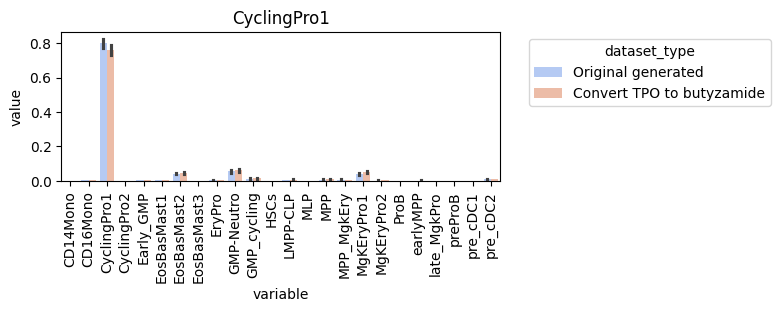

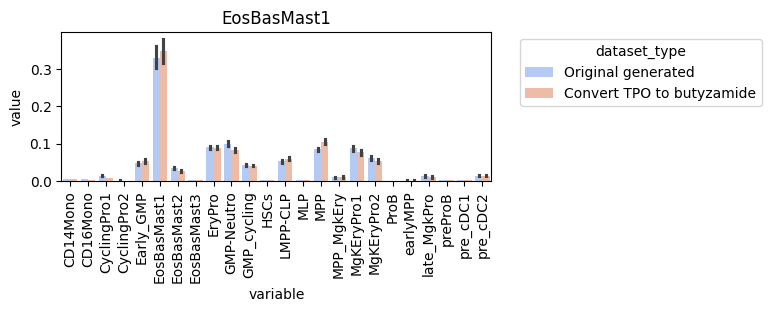

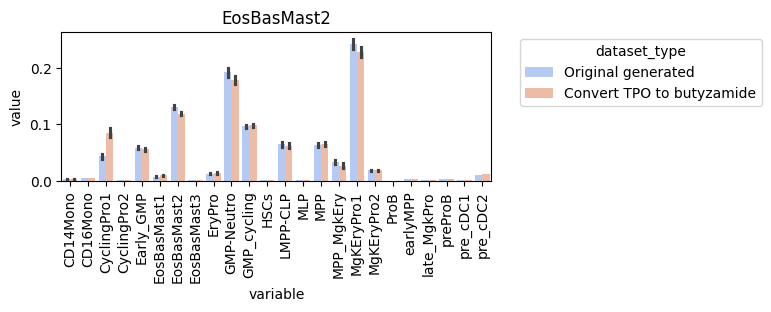

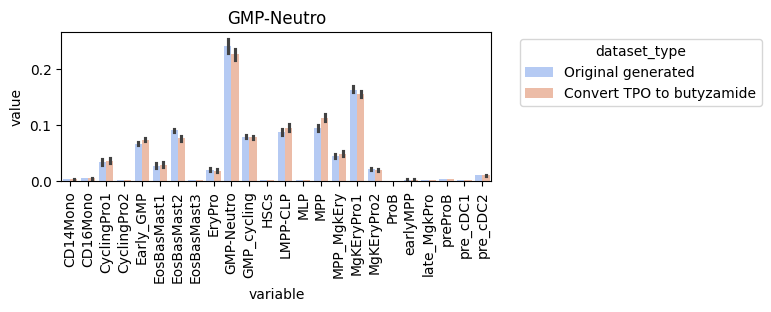

In [44]:
for cell_type in pred_df_cell_types:
    
    plt.figure(figsize=(8,3))
    ax = sns.barplot(
        data=pred_df_cell_types[cell_type],
        x="variable",
        y="value",
        hue="dataset_type",
        palette="coolwarm"
    )
    
    plt.xticks(rotation=90)
    
    # Place legend outside
    ax.legend(title="dataset_type", bbox_to_anchor=(1.05, 1), loc="upper left")
    
    plt.tight_layout()
    plt.title(cell_type)
    plt.show()